<a href="https://colab.research.google.com/github/luanaketerlly/sales-data-analysis/blob/main/Tratamento_dataset_vendas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Comercial - Financial Dataset
**Objetivo:**  
*   Analisar o desempenho de vendas
*   Onde a empresa mais vende
*   Onde mais lucra
*   Onde está perdendo margem
*   O impacto dos descontos
*   Quais produtos e segmentos são mais estratégicos
*   Como o desempenho evolui ao longo do tempo







**Descrição do dataset:**  
O dataset contém informações de vendas, produtos, unidades vendidas, descontos, lucros e datas de transação.

##Documentação de projeto


[Clique aqui para abrir o PDF com resumo sobre o Dataset](https://drive.google.com/file/d/1Satg7MCapRGK4G9A2w0VmBhAGzlQz_as/view?usp=drive_link)

##Importação de bibliotecas / arquivo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
#Configurações gráficas
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Projeto-analise-vendas/data/dataset_original.csv')

##Checagem de Dataset

In [4]:
df.head()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
0,Government,Canada,Carretera,None,"$1,618.50",$3.00,$20.00,"$32,370.00",$-,"$32,370.00","$16,185.00","$16,185.00",01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,"$1,321.00",$3.00,$20.00,"$26,420.00",$-,"$26,420.00","$13,210.00","$13,210.00",01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,"$2,178.00",$3.00,$15.00,"$32,670.00",$-,"$32,670.00","$21,780.00","$10,890.00",01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,$888.00,$3.00,$15.00,"$13,320.00",$-,"$13,320.00","$8,880.00","$4,440.00",01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,"$2,470.00",$3.00,$15.00,"$37,050.00",$-,"$37,050.00","$24,700.00","$12,350.00",01/06/2014,6,June,2014


In [5]:
df.columns

Index(['Segment', 'Country', ' Product ', ' Discount Band ', ' Units Sold ',
       ' Manufacturing Price ', ' Sale Price ', ' Gross Sales ', ' Discounts ',
       '  Sales ', ' COGS ', ' Profit ', 'Date', 'Month Number',
       ' Month Name ', 'Year'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

In [7]:
df.describe()

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


In [8]:
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [9]:
df.shape

(700, 16)

In [10]:
df.tail()

,Segment,Country,Product,Discount Band,Units Sold,Manufacturing Price,Sale Price,Gross Sales,Discounts,Sales,COGS,Profit,Date,Month Number,Month Name,Year
695,Small Business,France,Amarilla,High,"$2,475.00",$260.00,$300.00,"$7,42,500.00","$1,11,375.00","$6,31,125.00","$6,18,750.00","$12,375.00",01/03/2014,3,March,2014
696,Small Business,Mexico,Amarilla,High,$546.00,$260.00,$300.00,"$1,63,800.00","$24,570.00","$1,39,230.00","$1,36,500.00","$2,730.00",01/10/2014,10,October,2014
697,Government,Mexico,Montana,High,"$1,368.00",$5.00,$7.00,"$9,576.00","$1,436.40","$8,139.60","$6,840.00","$1,299.60",01/02/2014,2,February,2014
698,Government,Canada,Paseo,High,$723.00,$10.00,$7.00,"$5,061.00",$759.15,"$4,301.85","$3,615.00",$686.85,01/04/2014,4,April,2014
699,Channel Partners,United States of America,VTT,High,"$1,806.00",$250.00,$12.00,"$21,672.00","$3,250.80","$18,421.20","$5,418.00","$13,003.20",01/05/2014,5,May,2014


# Tratamento de Dados


1.   Limpeza de colunas financeiras
2.  Conversão de dados de colunas
1. Criação de novas colunas



##Parte 1 - Limpeza de colunas financeiras

In [11]:
#Verificando dados do Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Segment                700 non-null    object
 1   Country                700 non-null    object
 2    Product               700 non-null    object
 3    Discount Band         700 non-null    object
 4    Units Sold            700 non-null    object
 5    Manufacturing Price   700 non-null    object
 6    Sale Price            700 non-null    object
 7    Gross Sales           700 non-null    object
 8    Discounts             700 non-null    object
 9     Sales                700 non-null    object
 10   COGS                  700 non-null    object
 11   Profit                700 non-null    object
 12  Date                   700 non-null    object
 13  Month Number           700 non-null    int64 
 14   Month Name            700 non-null    object
 15  Year                   

In [12]:
#Verificando dados nulos do Dataset
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount Band,0
Units Sold,0
Manufacturing Price,0
Sale Price,0
Gross Sales,0
Discounts,0
Sales,0


In [13]:
#Verificando dados do Dataset
df.describe()

,Month Number,Year
count,700.000000,700.000000
mean,7.900000,2013.750000
std,3.377321,0.433322
min,1.000000,2013.000000
25%,5.750000,2013.750000
50%,9.000000,2014.000000
75%,10.250000,2014.000000
max,12.000000,2014.000000


In [14]:
#Removendo espaços extras dos nomes das colunas
df.columns = df.columns.str.strip().str.replace(' ', '_')

In [15]:
#Verificando se os espaços foram removidos
df.columns

Index(['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold',
       'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name',
       'Year'],
      dtype='object')

In [16]:
#Removendo símbolos de colunas monetárias
colunas_monetarias = ['Units_Sold','Manufacturing_Price','Sale_Price','Gross_Sales','Discounts','Sales','COGS','Profit']

for col in colunas_monetarias:
    df[col] = df[col].replace({'\$': '', ',': ''}, regex=True)

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_911/3331062191.py:5: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace({'\$': '', ',': ''}, regex=True)


In [17]:
#Conferindo a remoção dos símbolos
df.head()

,Segment,Country,Product,Discount_Band,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,COGS,Profit,Date,Month_Number,Month_Name,Year
0,Government,Canada,Carretera,None,1618.50,3.00,20.00,32370.00,-,32370.00,16185.00,16185.00,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.00,3.00,20.00,26420.00,-,26420.00,13210.00,13210.00,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.00,3.00,15.00,32670.00,-,32670.00,21780.00,10890.00,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.00,3.00,15.00,13320.00,-,13320.00,8880.00,4440.00,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.00,3.00,15.00,37050.00,-,37050.00,24700.00,12350.00,01/06/2014,6,June,2014


In [18]:
#Verificando valores nulos
df.isnull().sum()

,0
Segment,0
Country,0
Product,0
Discount_Band,0
Units_Sold,0
Manufacturing_Price,0
Sale_Price,0
Gross_Sales,0
Discounts,0
Sales,0


In [19]:
#Verificando a quantidade de valores únicos em cada coluna
df.nunique()

,0
Segment,5
Country,5
Product,6
Discount_Band,4
Units_Sold,510
Manufacturing_Price,6
Sale_Price,7
Gross_Sales,550
Discounts,515
Sales,559


In [20]:
#Transformando valores nulos representados por '-' em nan para que não influencie no andamento do projeto
import numpy as np

df['Discounts'] = df['Discounts'].str.strip()
df['Discounts'] = df['Discounts'].replace('-', np.nan)

In [21]:
#Verificando alteração de valores nulos na coluna 'Discounts'
df.head()

,Segment,Country,Product,Discount_Band,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,COGS,Profit,Date,Month_Number,Month_Name,Year
0,Government,Canada,Carretera,None,1618.50,3.00,20.00,32370.00,NaN,32370.00,16185.00,16185.00,01/01/2014,1,January,2014
1,Government,Germany,Carretera,None,1321.00,3.00,20.00,26420.00,NaN,26420.00,13210.00,13210.00,01/01/2014,1,January,2014
2,Midmarket,France,Carretera,None,2178.00,3.00,15.00,32670.00,NaN,32670.00,21780.00,10890.00,01/06/2014,6,June,2014
3,Midmarket,Germany,Carretera,None,888.00,3.00,15.00,13320.00,NaN,13320.00,8880.00,4440.00,01/06/2014,6,June,2014
4,Midmarket,Mexico,Carretera,None,2470.00,3.00,15.00,37050.00,NaN,37050.00,24700.00,12350.00,01/06/2014,6,June,2014


##Parte 2 - Conversão de dados de colunas

In [22]:
import numpy as np

# Definindo uma função para limpar strings numéricas
def clean_numeric_string(value):
    if isinstance(value, str):
      # Remove todos os espaços
        value = value.strip().replace(' ', '')
        # TRansformando números com parênteses para números negativos: (X) -> -X
        if value.startswith('(') and value.endswith(')'):
            value = '-' + value[1:-1]
       # Removendo todos os caracteres não numéricos restantes, exceto o ponto decimal
        value = value.replace('$', '').replace(',', '')
        # Explicitamente tratando '-' como NaN após outras substituições
        if value == '-':
            return np.nan
        # Convertendo strings vazias em NaN
        if value == '':
            return np.nan
    return value

colunas = ['Units_Sold', 'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

# Aplica a função de limpeza a cada coluna.
for col in colunas:
    df[col] = df[col].apply(clean_numeric_string)

# Converte as colunas limpas para o formato float.
df[colunas] = df[colunas].astype(float)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Segment              700 non-null    object 
 1   Country              700 non-null    object 
 2   Product              700 non-null    object 
 3   Discount_Band        700 non-null    object 
 4   Units_Sold           700 non-null    float64
 5   Manufacturing_Price  700 non-null    float64
 6   Sale_Price           700 non-null    float64
 7   Gross_Sales          700 non-null    float64
 8   Discounts            647 non-null    float64
 9   Sales                700 non-null    float64
 10  COGS                 700 non-null    float64
 11  Profit               695 non-null    float64
 12  Date                 700 non-null    object 
 13  Month_Number         700 non-null    int64  
 14  Month_Name           700 non-null    object 
 15  Year                 700 non-null    int

In [24]:
#Verificando tipos de variáveis (colunas)
df.dtypes

,0
Segment,object
Country,object
Product,object
Discount_Band,object
Units_Sold,float64
Manufacturing_Price,float64
Sale_Price,float64
Gross_Sales,float64
Discounts,float64
Sales,float64


In [25]:
#Alterando o tipo da coluna Date
df['Date'] = pd.to_datetime(df['Date'])

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Segment              700 non-null    object        
 1   Country              700 non-null    object        
 2   Product              700 non-null    object        
 3   Discount_Band        700 non-null    object        
 4   Units_Sold           700 non-null    float64       
 5   Manufacturing_Price  700 non-null    float64       
 6   Sale_Price           700 non-null    float64       
 7   Gross_Sales          700 non-null    float64       
 8   Discounts            647 non-null    float64       
 9   Sales                700 non-null    float64       
 10  COGS                 700 non-null    float64       
 11  Profit               695 non-null    float64       
 12  Date                 700 non-null    datetime64[ns]
 13  Month_Number         700 non-null  

##Parte 3 - Criação de novas colunas

In [27]:
#Criando a coluna "MARGEM"
#Definindo a fórmula com objetivo de obter a margem de lucro.
#A divisão Profit / Sales calcula a proporção do lucro em relação à receita.
df['Margin'] = df['Profit'] / df['Sales'] *100

In [28]:
#Criando a coluna "TICKET MÉDIO POR UNIDADE"
#A divisão Sales / Units_Sold calcula o valor médio de cada unidade vendida quanto em média cada produto foi vendido.
df['Average_Ticket_Per_Unit'] = df['Sales'] / df['Units_Sold']

In [29]:
#Criando a coluna "ANO-MÊS(YYYY-MM)"
df['Year_Month'] = df['Date'].dt.strftime('%Y-%m') #,dt.strftime(('%Y-%m) formata cada data para o padrão ano-mês')

In [30]:
#Criando a coluna "INDICADOR DE DESCONTO (SIM=1/NÃO=0)"
#A função lambda verifica se a coluna Discounts possui valor maior que 0, se sim, preenche com Yes, Senão, Com No.
df['Discount_indicator'] = df['Discounts'].apply(lambda x: 'Yes' if x > 0 else 'No')

In [31]:
#Criando a coluna "PERCENTUAL DE DESCONTO"
#A divisão Discounts / Gross_Sales calcula a proporção do desconto em relação às vendas brutas.
df['Discount_percentage'] = (df['Discounts'] / df['Gross_Sales']) * 100

In [32]:
#Conferindo se as colunas foram criadas corretamente
df.head()

,Segment,Country,Product,Discount_Band,Units_Sold,Manufacturing_Price,Sale_Price,Gross_Sales,Discounts,Sales,...,Profit,Date,Month_Number,Month_Name,Year,Margin,Average_Ticket_Per_Unit,Year_Month,Discount_indicator,Discount_percentage
0,Government,Canada,Carretera,None,1618.5,3.0,20.0,32370.0,NaN,32370.0,...,16185.0,2014-01-01,1,January,2014,50.000000,20.0,2014-01,No,NaN
1,Government,Germany,Carretera,None,1321.0,3.0,20.0,26420.0,NaN,26420.0,...,13210.0,2014-01-01,1,January,2014,50.000000,20.0,2014-01,No,NaN
2,Midmarket,France,Carretera,None,2178.0,3.0,15.0,32670.0,NaN,32670.0,...,10890.0,2014-01-06,6,June,2014,33.333333,15.0,2014-01,No,NaN
3,Midmarket,Germany,Carretera,None,888.0,3.0,15.0,13320.0,NaN,13320.0,...,4440.0,2014-01-06,6,June,2014,33.333333,15.0,2014-01,No,NaN
4,Midmarket,Mexico,Carretera,None,2470.0,3.0,15.0,37050.0,NaN,37050.0,...,12350.0,2014-01-06,6,June,2014,33.333333,15.0,2014-01,No,NaN


In [33]:
#Renomeando a coluna "MARGEM"
df.rename(columns={'Margin (%)': 'Margin'}, inplace=True)

In [34]:
#Verificando todas as colunas existentes no Dataset
df.columns

Index(['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold',
       'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name', 'Year',
       'Margin', 'Average_Ticket_Per_Unit', 'Year_Month', 'Discount_indicator',
       'Discount_percentage'],
      dtype='object')

In [35]:
#Conferindo tipos de colunas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Segment                  700 non-null    object        
 1   Country                  700 non-null    object        
 2   Product                  700 non-null    object        
 3   Discount_Band            700 non-null    object        
 4   Units_Sold               700 non-null    float64       
 5   Manufacturing_Price      700 non-null    float64       
 6   Sale_Price               700 non-null    float64       
 7   Gross_Sales              700 non-null    float64       
 8   Discounts                647 non-null    float64       
 9   Sales                    700 non-null    float64       
 10  COGS                     700 non-null    float64       
 11  Profit                   695 non-null    float64       
 12  Date                     700 non-nul

In [36]:
#Verificando colunas
df.columns

Index(['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold',
       'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts',
       'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name', 'Year',
       'Margin', 'Average_Ticket_Per_Unit', 'Year_Month', 'Discount_indicator',
       'Discount_percentage'],
      dtype='object')

### Fim do Checkpoint da semana 01

In [37]:
#Conferindo tamanho final do Dataset (700 linhas, 21 colunas)
df.shape

(700, 21)

In [38]:
# ==============================
# VERIFICAÇÃO FINAL DO DATASET
# ==============================

# verificar estrutura
df.info()

# verificar valores nulos
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# verificar duplicatas
print("\nLinhas duplicadas:", df.duplicated().sum())

# estatísticas das colunas numéricas
print("\nEstatísticas gerais:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Segment                  700 non-null    object        
 1   Country                  700 non-null    object        
 2   Product                  700 non-null    object        
 3   Discount_Band            700 non-null    object        
 4   Units_Sold               700 non-null    float64       
 5   Manufacturing_Price      700 non-null    float64       
 6   Sale_Price               700 non-null    float64       
 7   Gross_Sales              700 non-null    float64       
 8   Discounts                647 non-null    float64       
 9   Sales                    700 non-null    float64       
 10  COGS                     700 non-null    float64       
 11  Profit                   695 non-null    float64       
 12  Date                     700 non-nul

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Segment                  700 non-null    object        
 1   Country                  700 non-null    object        
 2   Product                  700 non-null    object        
 3   Discount_Band            700 non-null    object        
 4   Units_Sold               700 non-null    float64       
 5   Manufacturing_Price      700 non-null    float64       
 6   Sale_Price               700 non-null    float64       
 7   Gross_Sales              700 non-null    float64       
 8   Discounts                647 non-null    float64       
 9   Sales                    700 non-null    float64       
 10  COGS                     700 non-null    float64       
 11  Profit                   695 non-null    float64       
 12  Date                     700 non-nul

In [40]:
# ==============================
# EXPORTAR DATASET TRATADO
# ==============================
#df.to_csv('/content/drive/MyDrive/Projeto-analise-vendas/data/dataset_tratado_v6.csv', index=False)
#print("Dataset tratado salvo com sucesso no Google Drive.")

In [41]:
df.nunique()

,0
Segment,5
Country,5
Product,6
Discount_Band,4
Units_Sold,510
Manufacturing_Price,6
Sale_Price,7
Gross_Sales,550
Discounts,514
Sales,559


#Análise exploratória

**Pontos de análise:**
*   Qual país vende mais?
*   Qual país é mais lucrativo?
*   Qual segmento gera mais lucro?
*   Qual produto tem maior margem?
*   Descontos aumentam ou reduzem lucro?
*   Existe sazonalidade?
*   Existe produto que vende muito mas gera pouco?









##Qual país vende mais?
-	United States of America

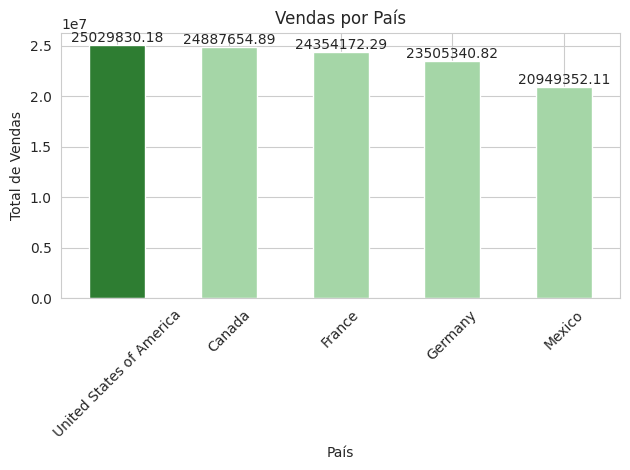

In [42]:

# Agrupar vendas por país e transferir para 'vendas_por_pais' deixando ordenado
vendas_por_pais = df.groupby('Country')['Sales'].sum().sort_values(ascending=False)

# Cores em verde
cores = ['#2e7d32' if i == 0 else '#a5d6a7' for i in range(len(vendas_por_pais))]

# Criar gráfico de barras
plt.figure()
vendas_por_pais.plot(kind='bar', color=cores)

# Títulos
plt.title('Vendas por País')
plt.xlabel('País')
plt.ylabel('Total de Vendas')

# Ajustes visuais
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar valores nas barras
for i, v in enumerate(vendas_por_pais):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.show()

##Qual país é mais lucrativo?

-United States of America



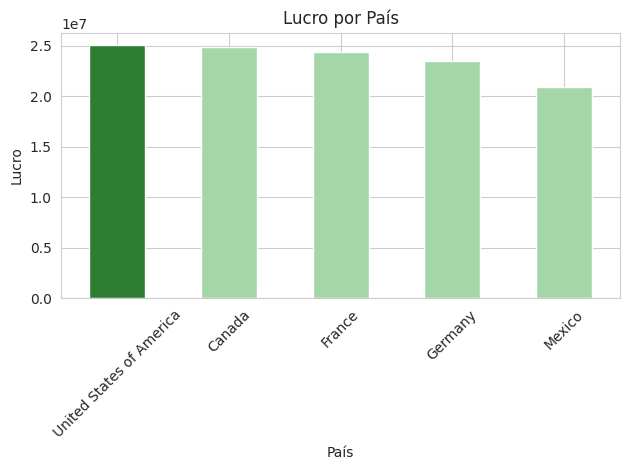

In [43]:

# Agrupando os lucros por país e ordenando
lucro_pais = df.groupby('Country')['Profit'].sum().sort_values(ascending=False)

# Cores em verde
cores = ['#2e7d32' if i == 0 else '#a5d6a7' for i in range(len(vendas_por_pais))]

# Criar gráfico de barras
plt.figure()
vendas_por_pais.plot(kind='bar', color=cores)

# Títulos
plt.title('Lucro por País')
plt.xlabel('País')
plt.ylabel('Lucro')

# Ajuste visual
plt.xticks(rotation=45)
plt.tight_layout()

# Rotacionar nomes dos países (se necessário)
plt.xticks(rotation=45)

# Exibir
plt.show()

##Qual segmento gera mais lucro?
-Government

Segment
Government          11388173.18
Small Business       4143168.50
Channel Partners     1316803.14
Midmarket             660103.09
Enterprise           -614545.62
Name: Profit, dtype: float64


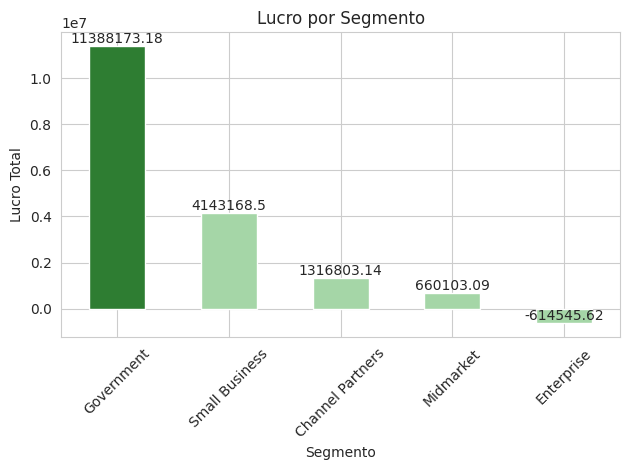

In [44]:

# Agrupar lucro por segmento
lucro_segmento = df.groupby('Segment')['Profit'].sum().sort_values(ascending=False)

# Ver no console
print(lucro_segmento)

# Cores em verde (destacar o mais lucrativo)
cores = ['#2e7d32' if i == 0 else '#a5d6a7' for i in range(len(lucro_segmento))]

# Criar gráfico
plt.figure()
lucro_segmento.plot(kind='bar', color=cores)

# Títulos
plt.title('Lucro por Segmento')
plt.xlabel('Segmento')
plt.ylabel('Lucro Total')

# Ajustes visuais
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar valores nas barras
for i, v in enumerate(lucro_segmento):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.show()

##Qual produto tem maior margem? (Equilíbrio = margem x venda)
-Paseo

In [45]:

# Agrupar por produto
analise_produto = df.groupby('Product').agg({
    'Sales': 'sum',
    'Margin': 'mean'
})

# Normalizar (colocar na mesma escala 0 a 1)
analise_produto['Sales_norm'] = (analise_produto['Sales'] - analise_produto['Sales'].min()) / (analise_produto['Sales'].max() - analise_produto['Sales'].min())

analise_produto['Margin_norm'] = (analise_produto['Margin'] - analise_produto['Margin'].min()) / (analise_produto['Margin'].max() - analise_produto['Margin'].min())

# Criar score combinado
analise_produto['Score'] = analise_produto['Sales_norm'] + analise_produto['Margin_norm']

# Ordenar
analise_produto = analise_produto.sort_values(by='Score', ascending=False)

# Mostrar resultado
print(analise_produto)

                  Sales     Margin  Sales_norm  Margin_norm     Score
Product                                                              
Paseo       33011143.96  28.981201    1.000000     0.827805  1.827805
Amarilla    17747116.07  29.304270    0.204826     0.930481  1.135307
Carretera   13815307.89  29.523012    0.000000     1.000000  1.000000
Montana     15390801.88  27.505168    0.082075     0.358701  0.440776
VTT         20511921.02  26.376518    0.348858     0.000000  0.348858
Velo        18250059.47  26.485845    0.231027     0.034746  0.265772


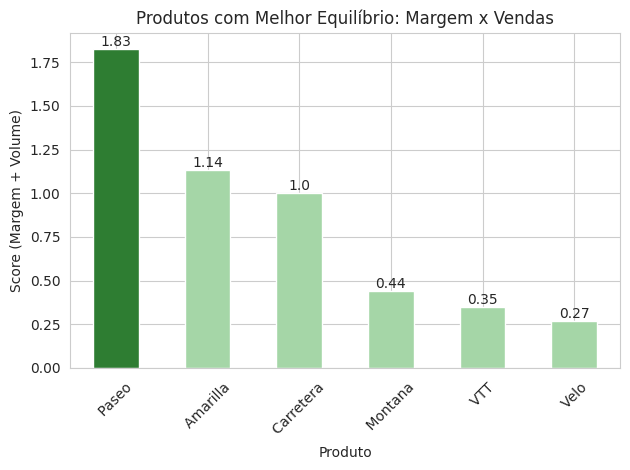

In [46]:
# Cores
cores = ['#2e7d32' if i == 0 else '#a5d6a7' for i in range(len(analise_produto))]

plt.figure()
analise_produto['Score'].plot(kind='bar', color=cores)

plt.title('Produtos com Melhor Equilíbrio: Margem x Vendas')
plt.xlabel('Produto')
plt.ylabel('Score (Margem + Volume)')

plt.xticks(rotation=45)
plt.tight_layout()

# Valores nas barras
for i, v in enumerate(analise_produto['Score']):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.show()

##Descontos aumentam ou reduzem lucro?
-Os descontos diminuem o lucro.

Discount_Band
Low        39928.114258
None       32763.301887
Medium     23055.879504
High       13832.109143
Name: Profit, dtype: float64


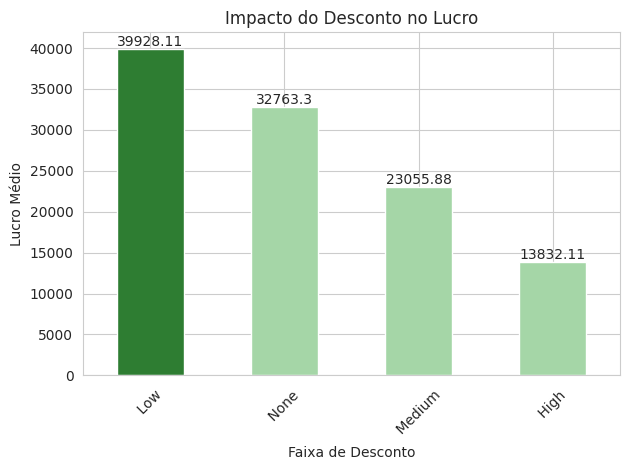

In [54]:

# Agrupando valores
lucro_desconto = df.groupby('Discount_Band')['Profit'].mean()

# Ordenando resultados
lucro_desconto = lucro_desconto.sort_values(ascending=False)

# Mostrar no console
print(lucro_desconto)

# Cores em verde (destacar melhor faixa)
cores = ['#2e7d32' if i == 0 else '#a5d6a7' for i in range(len(lucro_desconto))]

# Gráfico
plt.figure()
lucro_desconto.plot(kind='bar', color=cores)

plt.title('Impacto do Desconto no Lucro')
plt.xlabel('Faixa de Desconto')
plt.ylabel('Lucro Médio')

plt.xticks(rotation=45)
plt.tight_layout()

# Valores nas barras
for i, v in enumerate(lucro_desconto):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.show()

##Existe sazonalidade?
-Tendo em vista que a base de dados só tem registros do ano de 2013 a partir do mês de Setembro; As vendas apresentam sazonalidade, com picos em meses semelhantes entre os anos analisados.

In [69]:
#Criando uma base de vendas por ano
pivot = df.pivot_table(
    values='Units_Sold',
    index='Month_Number',
    columns='Year',
    aggfunc='sum'
)

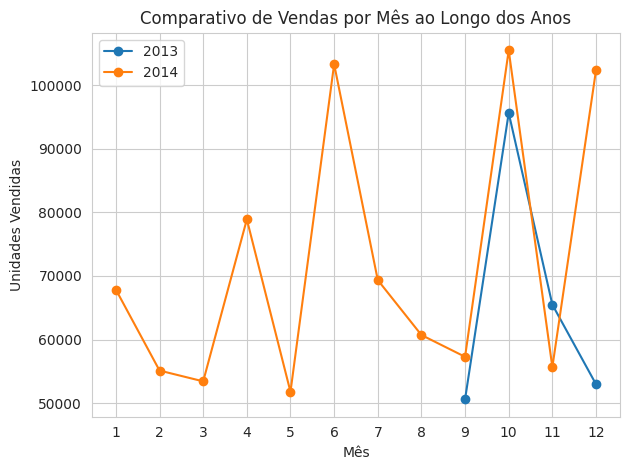

In [72]:
#Criando o gráfico comparativo entre os anos
plt.figure()

for ano in pivot.columns:
    plt.plot(pivot.index, pivot[ano], marker='o', label=ano)
#Criando os títulos do gráfico
plt.title('Comparativo de Vendas por Mês ao Longo dos Anos')
plt.xlabel('Mês')
plt.ylabel('Unidades Vendidas')
#Parte visual do gráfico
plt.xticks(range(1, 13))
plt.legend()

plt.tight_layout()
plt.show()

##Existe produto que vende muito mas gera pouco?
-Não, todos os produtos apresentam um bom índice de lucro comparado ás vendas.

In [82]:
#Criando listagem de vendas e lucro por produto
analise_produto = df.groupby('Product').agg({
    'Units_Sold': 'sum',
    'Profit': 'sum'
})

print(analise_produto)

            Units_Sold      Profit
Product                           
Amarilla      155315.0  2814104.07
Carretera     146846.0  1826804.89
Montana       154198.0  2114754.88
Paseo         338239.5  4797437.96
VTT           168783.0  3034608.02
Velo          162424.5  2305992.47


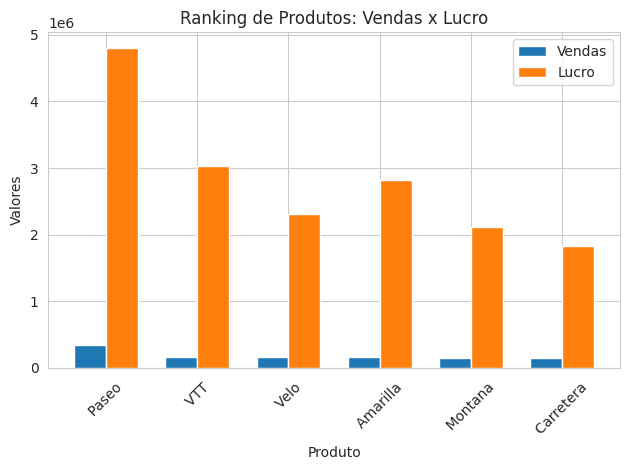

In [83]:

# Ordenando por vendas (Units_Sold)
analise_produto = analise_produto.sort_values(by='Units_Sold', ascending=False)

# Posições no eixo X
x = np.arange(len(analise_produto))

# Largura das barras
width = 0.35

plt.figure()

# Barras
plt.bar(x - width/2, analise_produto['Units_Sold'], width, label='Vendas')
plt.bar(x + width/2, analise_produto['Profit'], width, label='Lucro')

# Títulos
plt.title('Ranking de Produtos: Vendas x Lucro')
plt.xlabel('Produto')
plt.ylabel('Valores')

plt.xticks(x, analise_produto.index, rotation=45)

plt.legend()
plt.tight_layout()

plt.show()

### Fim do Checkpoint da semana 02